In [75]:
# coding: UTF-8
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import h5py
import csv
import math
from matplotlib.backends.backend_pdf import PdfPages

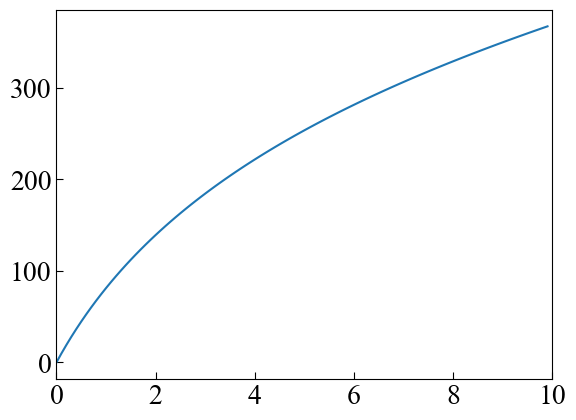

In [76]:
Vwv = 10.0 #km/s
Rho_ratio = 0.01 #rho_wd/rho_cld
Rcl = 20.0 #pc
M0 = 10 #v0/va+cs
A = 10.0 # for t=Myr


fig = plt.figure()
ax = fig.add_subplot(111)

plt.rcParams["font.family"] = "Times New Roman"      #全体のフォントを設定
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['mathtext.default'] = 'it'
plt.rcParams["xtick.direction"] = "in"               #x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams["ytick.direction"] = "in"               #y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
#plt.rcParams["xtick.minor.visible"] = True          #x軸補助目盛りの追加
#plt.rcParams["ytick.minor.visible"] = True          #y軸補助目盛りの追加
#plt.rcParams["xtick.major.width"] = 1.5              #x軸主目盛り線の線幅
#plt.rcParams["ytick.major.width"] = 1.5              #y軸主目盛り線の線幅
#plt.rcParams["xtick.minor.width"] = 1.0              #x軸補助目盛り線の線幅
#plt.rcParams["ytick.minor.width"] = 1.0              #y軸補助目盛り線の線幅
plt.rcParams["xtick.major.size"] = 5                #x軸主目盛り線の長さ
plt.rcParams["ytick.major.size"] = 5                #y軸主目盛り線の長さ
#plt.rcParams["xtick.minor.size"] = 5                #x軸補助目盛り線の長さ
#plt.rcParams["ytick.minor.size"] = 5                #y軸補助目盛り線の長さ
plt.rcParams["font.size"] = 20                       #フォントの大きさ
#plt.rcParams["axes.linewidth"] = 1.5                 #囲みの太さ
#plt.xlim([-1.0, 2000.0]) # x方向の描画範囲を指定
#plt.ylim([0.001, 1.0]) # y方向の描画範囲を指定
plt.rcParams["legend.markerscale"] = 2
plt.rcParams["legend.fancybox"] = False
plt.rcParams["legend.framealpha"] = 1
plt.rcParams["legend.edgecolor"] = 'black'

ax.set_xlim([0, 10]) # x方向の描画範囲を指定
#ax.set_ylim([1, 100]) # x方向の描画範囲を指定
#ax.set_ylim([1000, 1000000]) # x方向の描画範囲を指定

t = np.arange(0, 10, 0.1)
v = Vwv* (M0+1.0+(M0-1.0)*np.exp(-2.0*A*Vwv*Rho_ratio/Rcl*t) )/(M0+1.0-(M0-1.0)*np.exp(-2.0*A*Vwv*Rho_ratio/Rcl*t))
x = -Vwv*t+(Rcl*np.log(-(M0-1.0)/(M0+1.0)+np.exp(2.0*A*Vwv*Rho_ratio*t/Rcl))/A/Rho_ratio)-(Rcl*np.log(-(M0-1.0)/(M0+1.0) +1.0)/A/Rho_ratio)
#x = -Vwv*t+(Rcl*np.log((M0-1.0)/(M0+1.0)+np.exp(2.0*A*Vwv*Rho_ratio*t/Rcl))/A/Rho_ratio)-(Rcl*np.log((M0-1.0)/(M0+1.0) +1.0)/A/Rho_ratio)


plt.plot(t, x)
plt.show()

In [62]:
#import sympy as sym
import sympy as sp
from sympy import *

In [63]:
sp.var('M0, V_w, rho_r, R_c, t, v, x,A')

(M0, V_w, rho_r, R_c, t, v, x, A)

In [64]:
#v = sp.Function('v')(x)
x = sp.Function('x')(t)

In [40]:
eq1 = sp.Eq(sp.diff(x , t),  V_w* (M0+1.0+(M0-1.0)*sp.exp(-2.0*A*V_w*rho_r/R_c*t) )/(M0+1.0-(M0-1.0)*sp.exp(-2.0*A*V_w*rho_r/R_c*t)))
eq1

Eq(Derivative(x(t), t), V_w*(M0 + (M0 - 1.0)*exp(-2.0*A*V_w*rho_r*t/R_c) + 1.0)/(M0 - (M0 - 1.0)*exp(-2.0*A*V_w*rho_r*t/R_c) + 1.0))

In [49]:
sp.dsolve(eq1,ics={x.subs(t,0):0})

Eq(x(t), -1.0*V_w*t + 1.0*R_c*log((1.0 - 1.0*M0)/(1.0*M0 + 1.0) + 1.0*exp(2.0*A*V_w*rho_r*t/R_c))/(A*rho_r) - R_c*log(-M0/(M0 + 1.0) + 1.0 + 1/(M0 + 1.0))/(A*rho_r))

In [48]:
eq2 = sp.Eq(sp.diff(x , t),  V_w* (M0+1.0-(M0-1.0)*sp.exp(-2.0*A*V_w*rho_r/R_c*t) )/(M0+1.0+(M0-1.0)*sp.exp(-2.0*A*V_w*rho_r/R_c*t)))
eq2
sp.dsolve(eq2,ics={x.subs(t,0):0})

Eq(x(t), -1.0*V_w*t + 1.0*R_c*log((1.0*M0 - 1.0)/(1.0*M0 + 1.0) + 1.0*exp(2.0*A*V_w*rho_r*t/R_c))/(A*rho_r) - R_c*log(M0/(M0 + 1.0) + 1.0 - 1/(M0 + 1.0))/(A*rho_r))

In [163]:
#v = sp.Function('v')(x)
sp.var('M0, V_w, rho_r, R_c, t, v, x,A,v_a,v_0,M_cl,pi')
v = sp.Function('v')(t)

In [164]:
#eq2 = sp.Eq(sp.diff(v , t),  -rho_r*v*v*R_c*R_c*(1.0+v_a*v_a/v/v))
eq2 = sp.Eq(sp.diff(v , t),  -rho_r*v*v/R_c*(1.0)/(4*pi/3)*(1.0+v_a*v_a/v/v))
eq2

Eq(Derivative(v(t), t), -0.75*rho_r*(v_a**2/v(t)**2 + 1.0)*v(t)**2/(R_c*pi))

In [167]:
#sp.dsolve(eq2,ics={v.subs(t,0):-v_0})
sp.dsolve(eq2)

Eq(v(t), -1.0*v_a**1.0*(I**1.0*exp(I*v_a*(2.0*C1*R_c*pi - 1.5*rho_r*t)/(R_c*pi)) - (-I)**1.0)/(exp(I*v_a*(2.0*C1*R_c*pi - 1.5*rho_r*t)/(R_c*pi)) - 1))

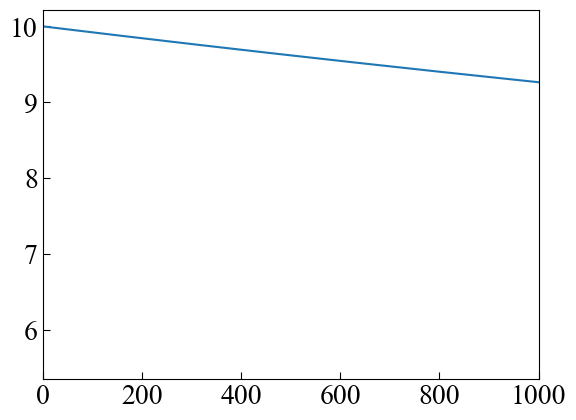

In [160]:
kms=10.0*5
pc=3.0*10.0**18
tMyr=10.0**6 * 3.0 * 10**7

Vwv = 10.0 * kms
Rho_ratio = 0.1 #rho_wd/rho_cld
Rcl = 20.0*pc
M0 = 10 #v0/va+cs
A = 10.0# for t=Myr
#tMyr= tMyr
V0=100.0 * kms
pi=3.1415926535

#dstop=Rcl/Rho_ratio*

fig = plt.figure()
ax = fig.add_subplot(111)

plt.rcParams["font.family"] = "Times New Roman"      #全体のフォントを設定
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['mathtext.default'] = 'it'
plt.rcParams["xtick.direction"] = "in"               #x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams["ytick.direction"] = "in"               #y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
#plt.rcParams["xtick.minor.visible"] = True          #x軸補助目盛りの追加
#plt.rcParams["ytick.minor.visible"] = True          #y軸補助目盛りの追加
#plt.rcParams["xtick.major.width"] = 1.5              #x軸主目盛り線の線幅
#plt.rcParams["ytick.major.width"] = 1.5              #y軸主目盛り線の線幅
#plt.rcParams["xtick.minor.width"] = 1.0              #x軸補助目盛り線の線幅
#plt.rcParams["ytick.minor.width"] = 1.0              #y軸補助目盛り線の線幅
plt.rcParams["xtick.major.size"] = 5                #x軸主目盛り線の長さ
plt.rcParams["ytick.major.size"] = 5                #y軸主目盛り線の長さ
#plt.rcParams["xtick.minor.size"] = 5                #x軸補助目盛り線の長さ
#plt.rcParams["ytick.minor.size"] = 5                #y軸補助目盛り線の長さ
plt.rcParams["font.size"] = 20                       #フォントの大きさ
#plt.rcParams["axes.linewidth"] = 1.5                 #囲みの太さ
#plt.xlim([-1.0, 2000.0]) # x方向の描画範囲を指定
#plt.ylim([0.001, 1.0]) # y方向の描画範囲を指定
plt.rcParams["legend.markerscale"] = 2
plt.rcParams["legend.fancybox"] = False
plt.rcParams["legend.framealpha"] = 1
plt.rcParams["legend.edgecolor"] = 'black'

ax.set_xlim([0, 1000]) # x方向の描画範囲を指定
#ax.set_ylim([0, 100]) # x方向の描画範囲を指定
#ax.set_ylim([1000, 1000000]) # x方向の描画範囲を指定

t = np.arange(0, 10000, 0.1)
#v = Vwv/np.tan(Vwv*(-Rcl*Rcl*Rho_ratio*t+np.arctan(Vwv/V0)/Vwv))
#v = -Vwv/(np.tan(Vwv*(-Rcl*Rcl*Rho_ratio*t))+ Vwv/V0)
v =(Rcl*pi/(Rcl*pi/V0+0.75*Rho_ratio+t*tMyr))/kms

plt.plot(t, v)
plt.show()